**Index No.:** 230280L  
**Name:** J. A. P. R. Jayasinghe  

# EN3160 Assignment 1
## Intensity Transformations and Neighborhood Filtering

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

**Question 1**

In [2]:
def intensity_transform(im, breakpoints):
    breakpoints = np.array(breakpoints, dtype=np.float64)

    im_float = im.astype(np.float64)
    out = np.zeros_like(im_float)

    for i in range(len(breakpoints) - 1):
        x0, y0 = breakpoints[i]
        x1, y1 = breakpoints[i + 1]

        if x1 == x0:
            continue  # vertical jump, no input range to map

        mask = (im_float >= x0) & (im_float < x1)
        slope = (y1 - y0) / (x1 - x0)
        out[mask] = y0 + slope * (im_float[mask] - x0)

    out[im_float == breakpoints[-1, 0]] = breakpoints[-1, 1]
    out = np.clip(out, 0, 255).astype(np.uint8)

    # Build a 256-point curve for plotting only
    all_x = np.arange(256, dtype=np.float64)
    curve = np.zeros_like(all_x)
    for i in range(len(breakpoints) - 1):
        x0, y0 = breakpoints[i]
        x1, y1 = breakpoints[i + 1]
        if x1 == x0:
            continue
        mask = (all_x >= x0) & (all_x < x1)
        slope = (y1 - y0) / (x1 - x0)
        curve[mask] = y0 + slope * (all_x[mask] - x0)
    curve[-1] = breakpoints[-1, 1]

    return out, curve

In [3]:
img = cv.imread('Images/img1.jpeg', cv.IMREAD_GRAYSCALE)

breakpoints = [
    [0, 0],
    [50, 50],
    [50, 100],
    [100, 175],
    [150, 255],
    [150, 150],
    [255, 255],
]

transformed, curve = intensity_transform(img, breakpoints)

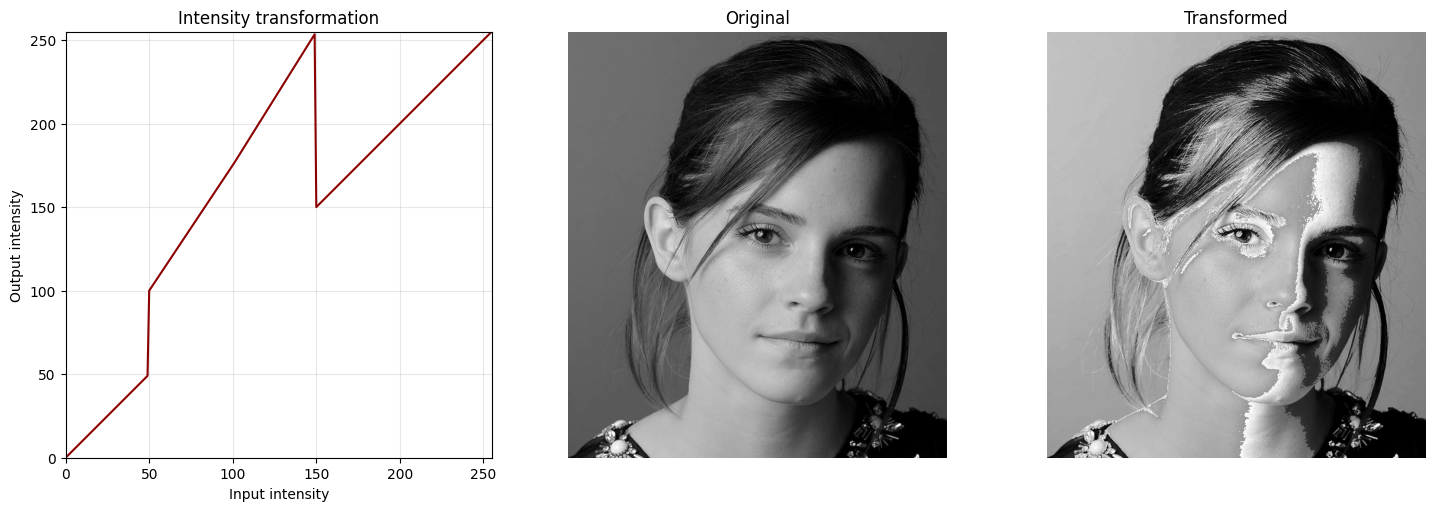

In [4]:
# Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(np.arange(256), curve, color='darkred')
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].set_xlabel('Input intensity')
axes[0].set_ylabel('Output intensity')
axes[0].set_title('Intensity transformation')
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')

axes[1].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Original')
axes[1].axis('off')

axes[2].imshow(transformed, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Transformed')
axes[2].axis('off')

plt.tight_layout()
plt.show()

**Question 2**

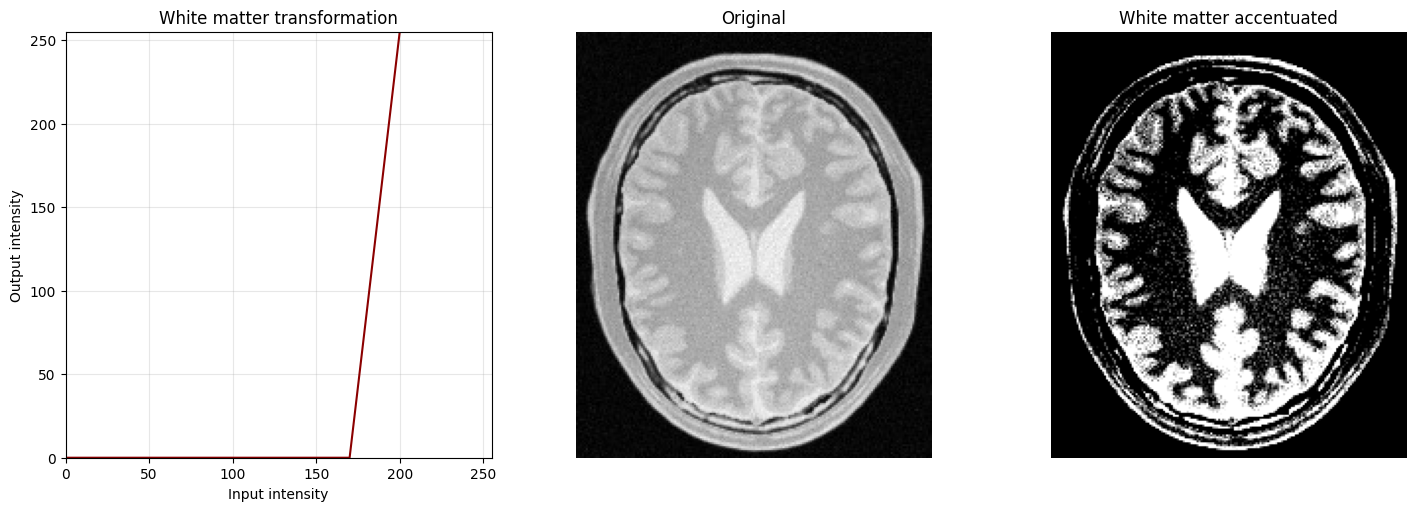

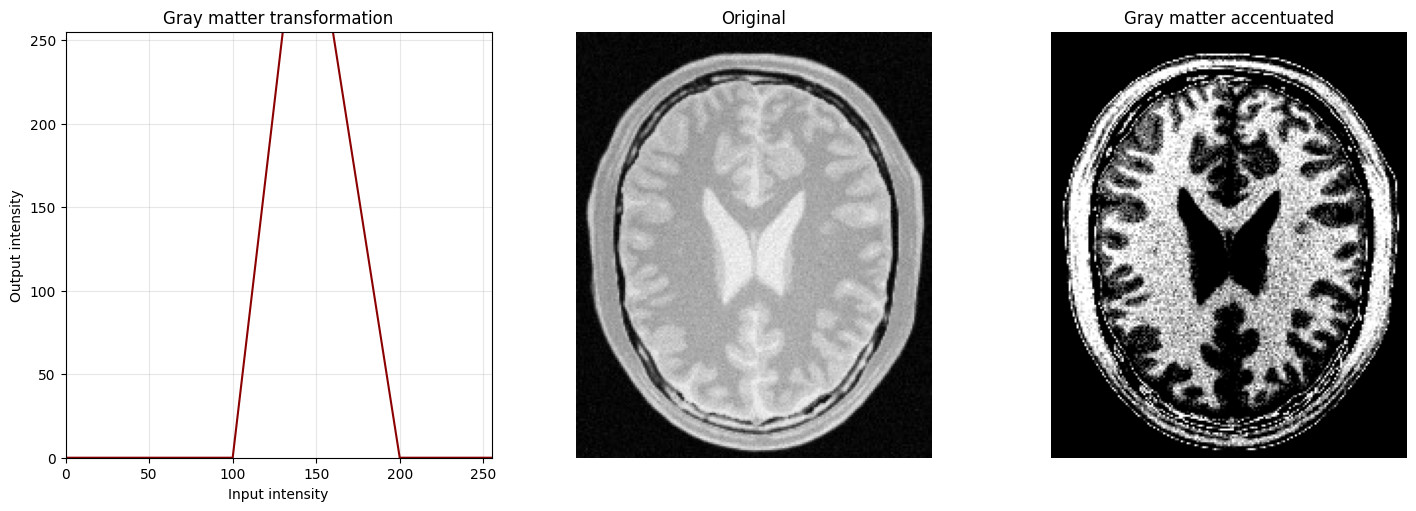

In [5]:
brain = cv.imread('Images/img2.jpeg', cv.IMREAD_GRAYSCALE)

# Transform all white matter to maximum intensity.
white_matter_breakpoints = [
    [0, 0],
    [170, 0],
    [200, 255],
    [255, 255],
]

# Tranform all gray matter to maximum intensity
gray_matter_breakpoints = [
    [0, 0],
    [100, 0],
    [130, 255],
    [160, 255],
    [200, 0],
    [255, 0],
]

white_out, white_curve = intensity_transform(brain, white_matter_breakpoints)
gray_out, gray_curve = intensity_transform(brain, gray_matter_breakpoints)

# White matter plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].plot(np.arange(256), white_curve, color='darkred')
axes[0].set_xlim(0, 255); axes[0].set_ylim(0, 255)
axes[0].set_xlabel('Input intensity'); axes[0].set_ylabel('Output intensity')
axes[0].set_title('White matter transformation')
axes[0].grid(True, alpha=0.3); axes[0].set_aspect('equal')

axes[1].imshow(brain, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Original'); axes[1].axis('off')

axes[2].imshow(white_out, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('White matter accentuated'); axes[2].axis('off')

plt.tight_layout()
plt.show()

# Gray matter plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].plot(np.arange(256), gray_curve, color='darkred')
axes[0].set_xlim(0, 255); axes[0].set_ylim(0, 255)
axes[0].set_xlabel('Input intensity'); axes[0].set_ylabel('Output intensity')
axes[0].set_title('Gray matter transformation')
axes[0].grid(True, alpha=0.3); axes[0].set_aspect('equal')

axes[1].imshow(brain, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Original'); axes[1].axis('off')

axes[2].imshow(gray_out, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Gray matter accentuated'); axes[2].axis('off')

plt.tight_layout()
plt.show()

**Question 3**

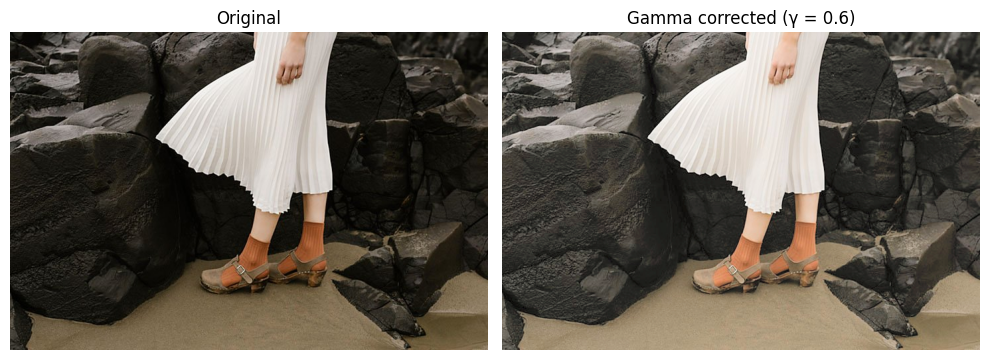

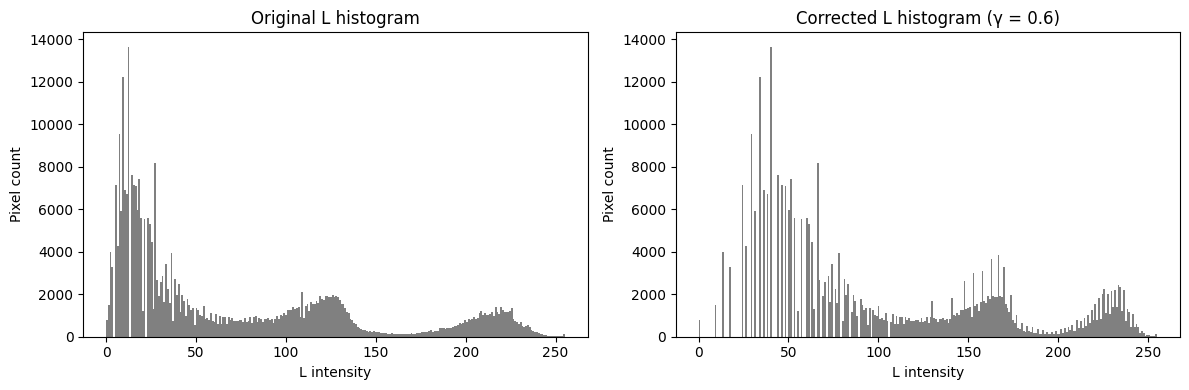

In [6]:
img_bgr = cv.imread('Images/img3.jpeg', cv.IMREAD_COLOR)
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

# Convert to L*a*b* 
lab = cv.cvtColor(img_bgr, cv.COLOR_BGR2LAB)
L, a, b = cv.split(lab)

# Apply gamma correction to the L plane
gamma = 0.6

L_norm = L.astype(np.float64) / 255.0
L_gamma = np.power(L_norm, gamma) * 255.0
L_gamma = np.clip(L_gamma, 0, 255).astype(np.uint8)

lab_corrected = cv.merge([L_gamma, a, b])
img_corrected_bgr = cv.cvtColor(lab_corrected, cv.COLOR_LAB2BGR)
img_corrected_rgb = cv.cvtColor(img_corrected_bgr, cv.COLOR_BGR2RGB)

# Original Image vs Gamma Corrected Image
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_rgb)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(img_corrected_rgb)
axes[1].set_title(f'Gamma corrected (γ = {gamma})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Histograms of the L plane
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(L.ravel(), bins=256, range=(0, 255), color='gray')
axes[0].set_title('Original L histogram')
axes[0].set_xlabel('L intensity')
axes[0].set_ylabel('Pixel count')

axes[1].hist(L_gamma.ravel(), bins=256, range=(0, 255), color='gray')
axes[1].set_title(f'Corrected L histogram (γ = {gamma})')
axes[1].set_xlabel('L intensity')
axes[1].set_ylabel('Pixel count')

plt.tight_layout()
plt.show()

**Question 4**

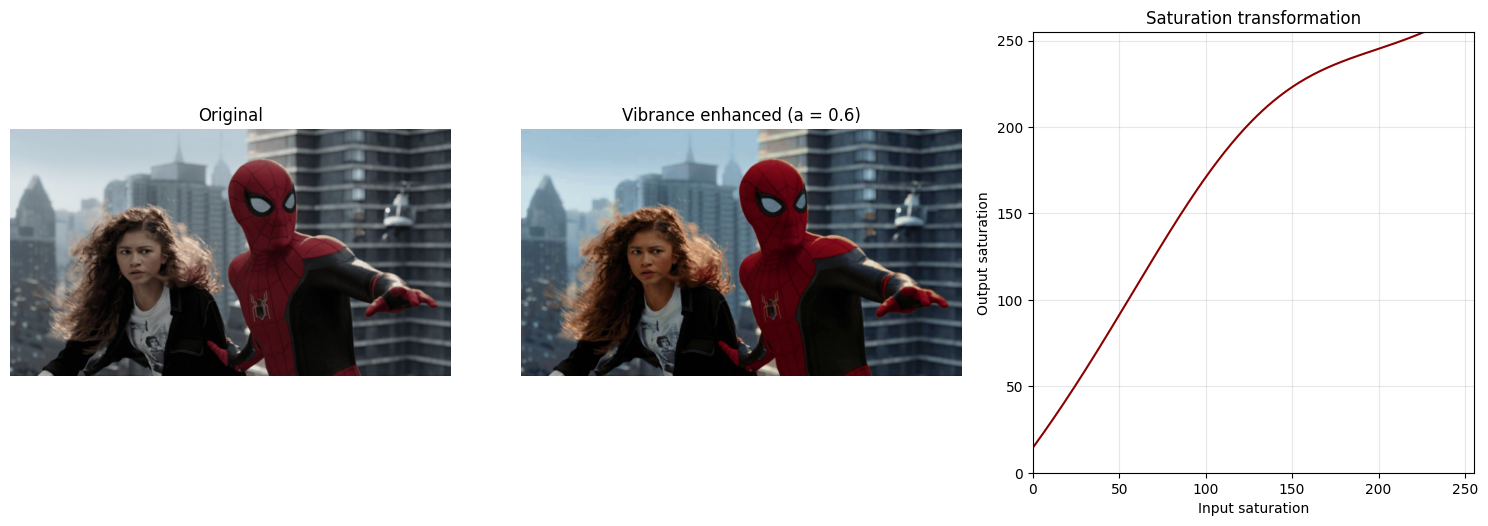

In [7]:
img_bgr = cv.imread('Images/img4.jpeg', cv.IMREAD_COLOR)
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

# (a) Split into hue, saturation, value planes
hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)
h, s, v = cv.split(hsv)

# (b) Vibrance transformation on the saturation plane
sigma = 70

def vibrance_transform(x, a, sigma=70):
    x = x.astype(np.float64)
    boosted = x + a * 128.0 * np.exp(-((x - 128.0) ** 2) / (2 * sigma ** 2))
    return np.clip(boosted, 0, 255)

# (c) Pick a
a = 0.6  

s_boosted = vibrance_transform(s, a, sigma).astype(np.uint8)

# (d) Recombine the three planes
hsv_boosted = cv.merge([h, s_boosted, v])
img_boosted_bgr = cv.cvtColor(hsv_boosted, cv.COLOR_HSV2BGR)
img_boosted_rgb = cv.cvtColor(img_boosted_bgr, cv.COLOR_BGR2RGB)

# (e) Display original, vibrance-enhanced, and the transformation curve
x_vals = np.arange(256)
curve = vibrance_transform(x_vals, a, sigma)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_rgb)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(img_boosted_rgb)
axes[1].set_title(f'Vibrance enhanced (a = {a})')
axes[1].axis('off')

axes[2].plot(x_vals, curve, color='darkred')
axes[2].set_xlim(0, 255)
axes[2].set_ylim(0, 255)
axes[2].set_xlabel('Input saturation')
axes[2].set_ylabel('Output saturation')
axes[2].set_title('Saturation transformation')
axes[2].grid(True, alpha=0.3)
axes[2].set_aspect('equal')

plt.tight_layout()
plt.show()

**Question 5**

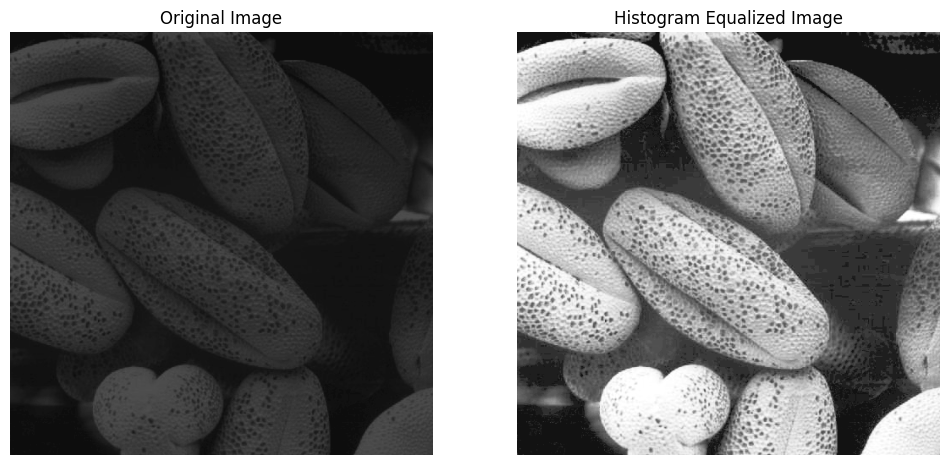

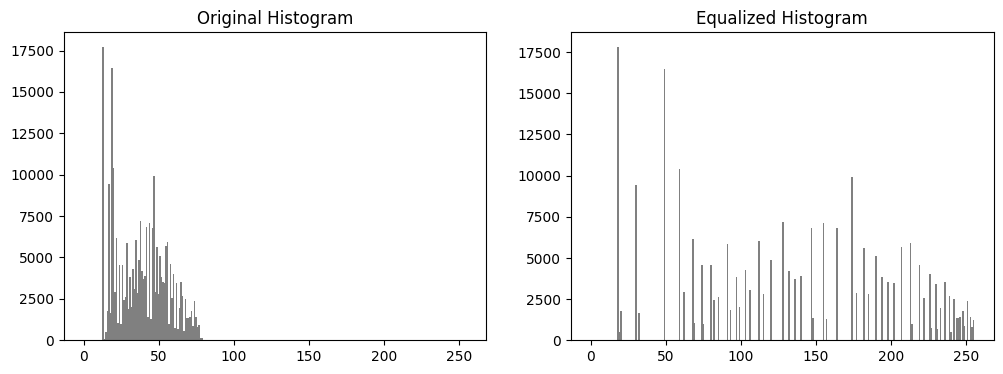

In [8]:
f = cv.imread('Images/img5.tif', cv.IMREAD_GRAYSCALE)

M, N = f.shape
L = 256

hist, _ = np.histogram(f, bins=L, range=(0, L))
cdf = np.cumsum(hist)

x = np.array(
    [round((L - 1) / (M * N) * cdf[k]) for k in range(L)],
    dtype=np.uint8
)

y = x[f]

# Original image vs Histogram equalized image
fig, ax = plt.subplots(1, 2, figsize=(12, 8))
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(y, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Histogram Equalized Image')
ax[1].axis('off')

plt.show()

# Histograms
hist_g, _ = np.histogram(y.ravel(), bins=L, range=(0, L))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(np.arange(L), hist, color='gray', width=1)
ax[0].set_title('Original Histogram')

ax[1].bar(np.arange(L), hist_g, color='gray', width=1)
ax[1].set_title('Equalized Histogram')

plt.show()

**Question 6**

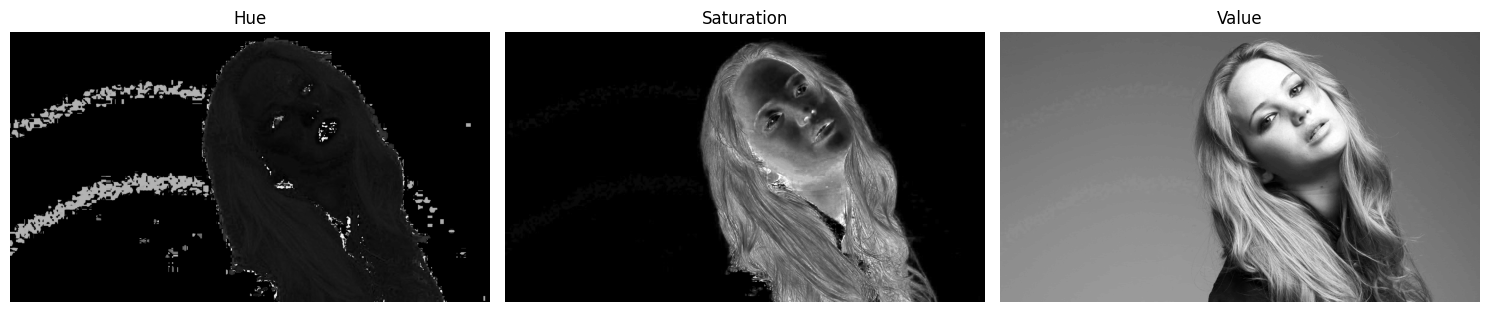

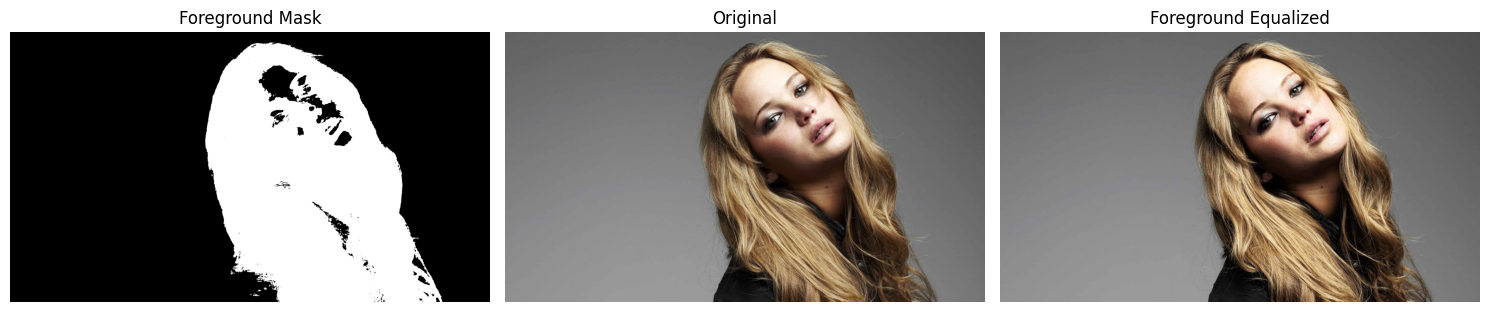

In [9]:
# (a) Split into H, S, V
img = cv.imread('Images/img6.jpeg', cv.IMREAD_COLOR)
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
h, s, v = cv.split(hsv)

# Plot H, S, V planes
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(h, cmap='gray'); ax[0].set_title('Hue'); ax[0].axis('off')
ax[1].imshow(s, cmap='gray'); ax[1].set_title('Saturation'); ax[1].axis('off')
ax[2].imshow(v, cmap='gray'); ax[2].set_title('Value'); ax[2].axis('off')
plt.tight_layout()
plt.show()

# (b) Select appropriate plane and threshold
_, mask = cv.threshold(s, 40, 255, cv.THRESH_BINARY)

# (c) Extract foreground and compute its histogram
foreground = cv.bitwise_and(img, img, mask=mask)
v_foreground = cv.bitwise_and(v, v, mask=mask)

# Histogram over foreground pixels only
fg_pixels = v[mask == 255]
hist, _ = np.histogram(fg_pixels, bins=256, range=(0, 256))

# (d) Cumulative sum
cdf = np.cumsum(hist)

# (e) Histogram equalize the foreground
L = 256
MN = fg_pixels.size

t = np.array([round((L - 1) / MN * cdf[k]) for k in range(L)], dtype=np.uint8)
v_eq_foreground = np.where(mask == 255, t[v], 0).astype(np.uint8)

# (f) Extract background and add with equalized foreground
background_mask = cv.bitwise_not(mask)
v_background = cv.bitwise_and(v, v, mask=background_mask)

v_result = cv.add(v_background, v_eq_foreground)

hsv_result = cv.merge([h, s, v_result])
result = cv.cvtColor(hsv_result, cv.COLOR_HSV2BGR)

# Display mask, original, and output images
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(mask, cmap='gray'); ax[0].set_title('Foreground Mask'); ax[0].axis('off')
ax[1].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB)); ax[1].set_title('Original'); ax[1].axis('off')
ax[2].imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB)); ax[2].set_title('Foreground Equalized'); ax[2].axis('off')
plt.tight_layout()
plt.show()

**Question 7**

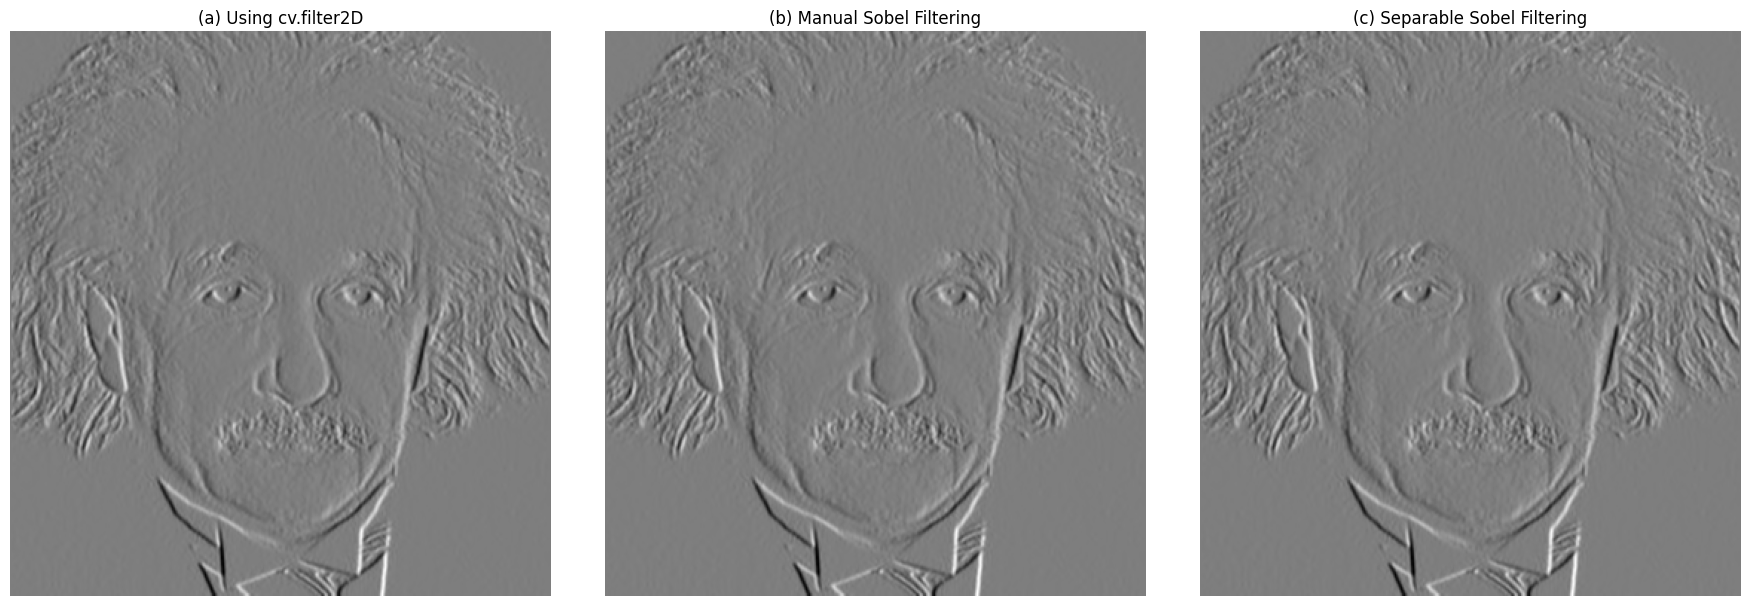

In [24]:
img = cv.imread('Images/img7.jpeg', cv.IMREAD_GRAYSCALE)

# (a) Using cvfilter2D to sobel horizontal filter 
sobel_x = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]])

img_x = cv.filter2D(img, cv.CV_64F, sobel_x)

# (b) Manual Sobel filtering
def sobel_filter(img, kernel):
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2

    # Reflect the image at the borders
    img_padded = np.pad(
        img.astype(np.float64),
        ((pad_h, pad_h), (pad_w, pad_w)),
        mode='reflect'
    )

    output = np.zeros_like(img, dtype=np.float64)

    # Apply the Sobel kernel manually
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = img_padded[i:i + kh, j:j + kw]
            output[i, j] = np.sum(region * kernel)

    return output

img_x_manual = sobel_filter(img, sobel_x)

# (c) Sobel filtering using separability
col_kernel = np.array([[1], [2], [1]], dtype=np.float64)
row_kernel = np.array([[1, 0, -1]], dtype=np.float64)

temp = cv.filter2D(img, cv.CV_64F, col_kernel)
img_x_separable = cv.filter2D(temp, cv.CV_64F, row_kernel)

# Output images
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(img_x, cmap='gray')
ax[0].set_title('(a) Using cv.filter2D')
ax[0].axis('off')

ax[1].imshow(img_x_manual, cmap='gray')
ax[1].set_title('(b) Manual Sobel Filtering')
ax[1].axis('off')

ax[2].imshow(img_x_separable, cmap='gray')
ax[2].set_title('(c) Separable Sobel Filtering')
ax[2].axis('off')

plt.tight_layout()
plt.show()


**Question 8**

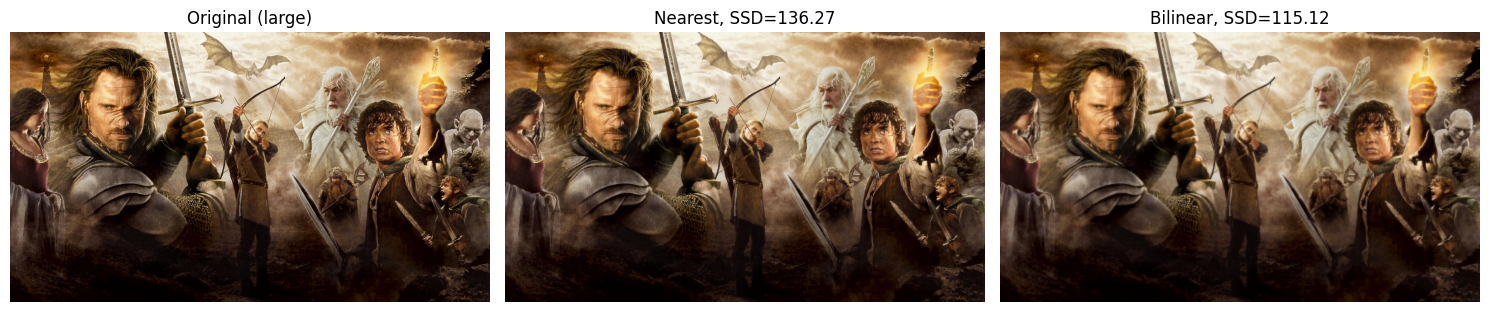

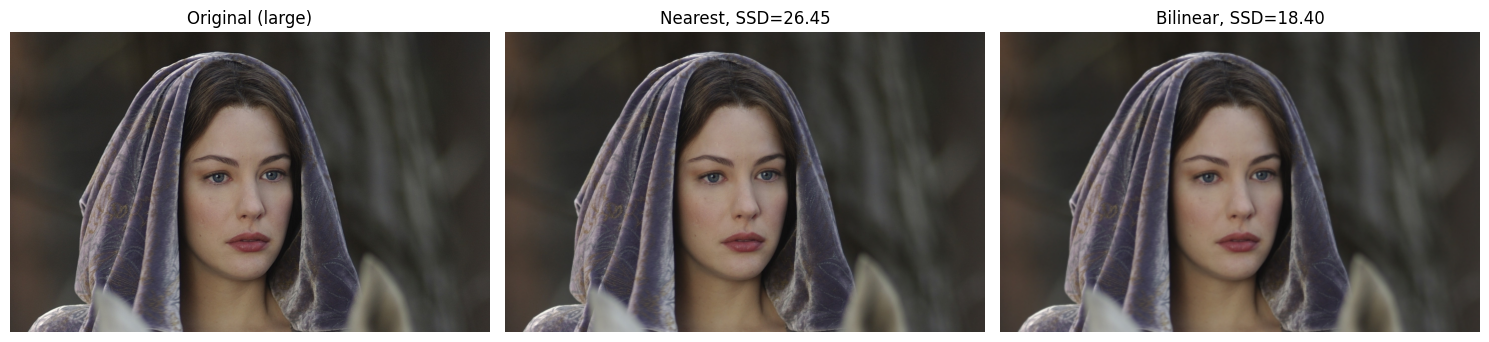

In [32]:
# Define function for zooming images using nearest neighbor and bilinear methods
def zoom_image(im, s, method='nearest'):
    im = im.astype(np.float64)
    H, W, _ = im.shape
    new_H, new_W = round(H * s), round(W * s)
    ys = (np.arange(new_H) + 0.5) / s - 0.5
    xs = (np.arange(new_W) + 0.5) / s - 0.5

    if method == 'nearest':
        yi = np.clip(np.round(ys), 0, H - 1).astype(int)
        xi = np.clip(np.round(xs), 0, W - 1).astype(int)
        out = im[yi][:, xi]
    else:  # bilinear
        y0 = np.clip(np.floor(ys), 0, H - 1).astype(int); y1 = np.clip(y0 + 1, 0, H - 1)
        x0 = np.clip(np.floor(xs), 0, W - 1).astype(int); x1 = np.clip(x0 + 1, 0, W - 1)
        wy = (ys - y0)[:, None, None]; wx = (xs - x0)[None, :, None]
        Ia, Ib, Ic, Id = im[y0][:, x0], im[y0][:, x1], im[y1][:, x0], im[y1][:, x1]
        out = (Ia * (1 - wx) + Ib * wx) * (1 - wy) + (Ic * (1 - wx) + Id * wx) * wy

    return np.clip(out, 0, 255).astype(np.uint8)

# Define function to calculate normalized SSD
def ssd(a, b):
    return np.sum((a.astype(np.float64) - b.astype(np.float64)) ** 2) / a.size

pairs = [('Images/img10small.png', 'Images/img10.png'),
         ('Images/img11small.png', 'Images/img11.png')]

for small_path, large_path in pairs:
    small = cv.cvtColor(cv.imread(small_path, cv.IMREAD_COLOR), cv.COLOR_BGR2RGB)
    original = cv.cvtColor(cv.imread(large_path, cv.IMREAD_COLOR), cv.COLOR_BGR2RGB)

    zoomed_nn = zoom_image(small, 4, 'nearest')
    zoomed_bl = zoom_image(small, 4, 'bilinear')

    h, w = min(zoomed_nn.shape[0], original.shape[0]), min(zoomed_nn.shape[1], original.shape[1])
    ssd_nn = ssd(zoomed_nn[:h, :w], original[:h, :w])
    ssd_bl = ssd(zoomed_bl[:h, :w], original[:h, :w])

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(original); ax[0].set_title('Original (large)'); ax[0].axis('off')
    ax[1].imshow(zoomed_nn); ax[1].set_title(f'Nearest, SSD={ssd_nn:.2f}'); ax[1].axis('off')
    ax[2].imshow(zoomed_bl); ax[2].set_title(f'Bilinear, SSD={ssd_bl:.2f}'); ax[2].axis('off')
    plt.tight_layout()
    plt.show()

**Question 9**

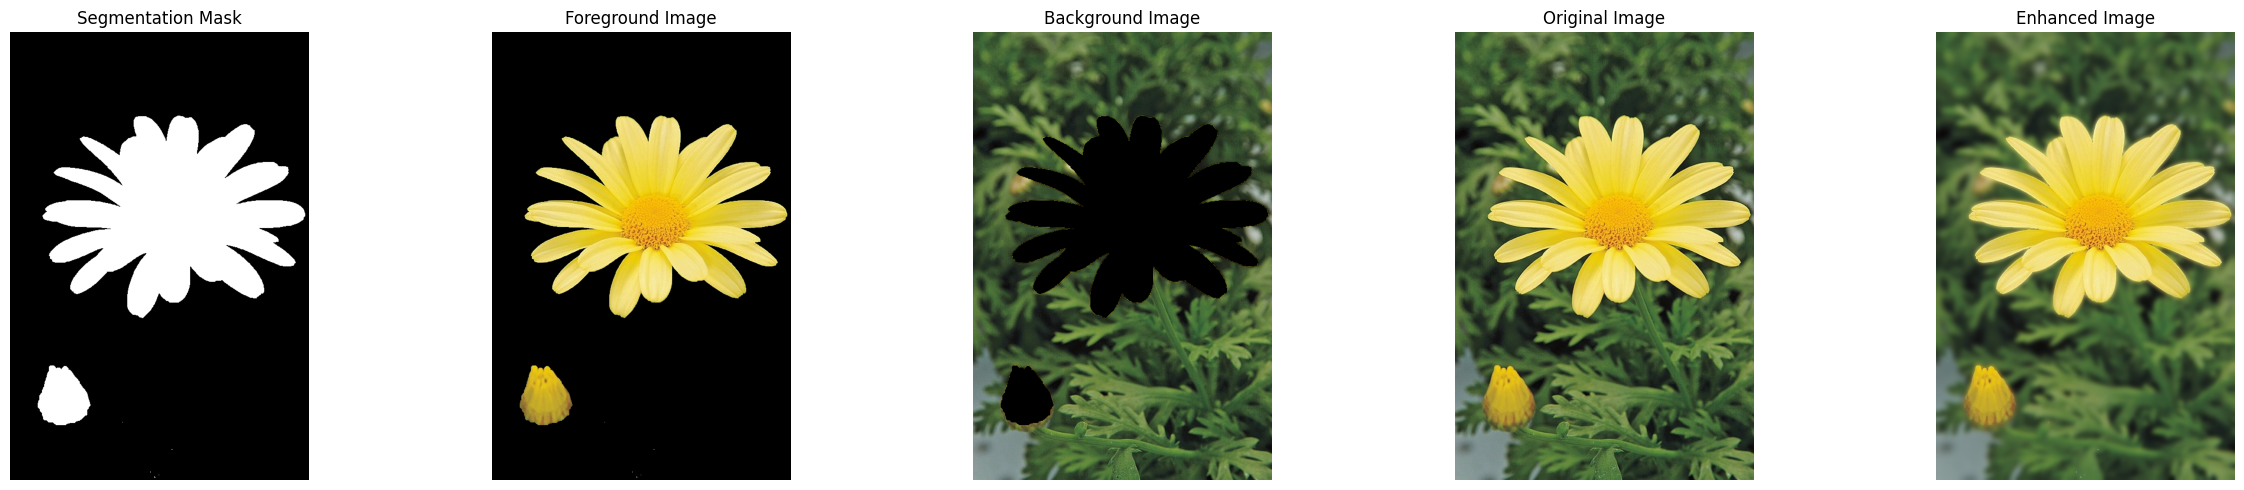

In [41]:
img = cv.imread('Images/img8.jpeg', cv.IMREAD_COLOR)

mask = np.zeros(img.shape[:2], np.uint8)
mask[:] = cv.GC_PR_BGD # Set the outer region as probable background
rect = (50, 20, img.shape[1] - 100, img.shape[0] - 40) # Rectangle containing the flower
x, y, w, h = rect
mask[y:y+h, x:x+w] = cv.GC_PR_FGD
cv.circle(mask, (300, 100), 40, cv.GC_BGD, -1)

# (a) Using GrabCut 
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)
cv.grabCut(img, mask, rect, bgdModel, fgdModel, 5, cv.GC_INIT_WITH_MASK)

# Extract foreground
mask2 = np.where((mask == cv.GC_FGD) | (mask == cv.GC_PR_FGD), 1, 0).astype(np.uint8) 
foreground = img * mask2[:, :, np.newaxis]

# Extract background
background = cv.subtract(img, foreground)

# (b) Enhanced image
blurred_full = cv.GaussianBlur(img, (25, 25), 0) 

mask_3ch = cv.merge([mask2] * 3)
enhanced = (img * mask_3ch + blurred_full * (1 - mask_3ch)).astype(np.uint8)

# Outputs
fig, ax = plt.subplots(1, 5, figsize=(25, 5))

ax[0].imshow(mask2, cmap='gray')
ax[0].set_title('Segmentation Mask')
ax[0].axis('off')

ax[1].imshow(cv.cvtColor(foreground, cv.COLOR_BGR2RGB))
ax[1].set_title('Foreground Image')
ax[1].axis('off')

ax[2].imshow(cv.cvtColor(background, cv.COLOR_BGR2RGB))
ax[2].set_title('Background Image')
ax[2].axis('off')

ax[3].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
ax[3].set_title('Original Image')
ax[3].axis('off')

ax[4].imshow(cv.cvtColor(enhanced, cv.COLOR_BGR2RGB))
ax[4].set_title('Enhanced Image')
ax[4].axis('off')

plt.tight_layout()
plt.show()

**Why is the background just beyond the edge of the flower quite dark in the enhanced image?**
Because of errors in the segmentation mask near the flower boundary. Some background pixels close to the flower are incorrectly classified or affected by the transition between foreground and background. When the blurred background is combined with the foreground, these boundary errors produce a dark region around the flower.